In [1]:
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from spin_lattices import SpinLattice, KagomeLattice
import numpy as np
import matplotlib.pyplot as plt
from vmc_amplitude import get_csr_hamiltonian, true_relsigns
from scipy.sparse import diags
import ising_glass_annealer as ising
from swo_validation_2023_09_14 import (
    configs,
    default_config,
    get_setup,
    output_dir,
    get_config,
    true_amplitudes,
)
from swo import generate_training_set
import pandas as pd
import seaborn as sns
from loguru import logger
import torch
from nqs_playground_helpers import sample_exactly, SamplingOptions
from torch.utils.data import DataLoader, TensorDataset
from misc_utils import torch_overlap
from collections.abc import Callable
import numpy.typing as npt
import sys
import os
from matplotlib.ticker import MaxNLocator
from ising_sign_reconstruction import reconstruct_signs, custom_signs, find_sign_overlap

In [2]:
task_id = 43
# lattice, system, _ = get_setup(task_id)

In [3]:
# system.get_eigenstates(1)
# ground_state = system.get_ground_state()
# output = []
# for iteration in [9, 19, 29, 39, 49, 59, 69, 79, 89, 99, 109, 119]:
#     predicted_amplitudes = np.sqrt(
#         np.load(output_dir / str(task_id) / f"log_prob_fn_{iteration}_predicted_probs.npy")
#     )

#     amplitude_overlap = predicted_amplitudes @ np.abs(ground_state)
#     print(f"{amplitude_overlap=}")
#     ising_hamiltonian_matrix = (
#         diags(predicted_amplitudes) @ get_csr_hamiltonian(system) @ diags(predicted_amplitudes)
#     )
#     ising_hamiltonian = ising.Hamiltonian(
#         exchange=ising_hamiltonian_matrix, field=np.zeros(ising_hamiltonian_matrix.shape[0])
#     )
#     reconstructed_signs = ising.bits_to_signs(
#         ising.anneal(ising_hamiltonian)[0], ising_hamiltonian.exchange.shape[0]
#     )
#     reconstructed_sign_overlap = np.abs(
#         ((reconstructed_signs * (np.sign(ground_state))) * ground_state**2).sum()
#     )
#     print(f"{reconstructed_sign_overlap=}")
#     output.append(
#         {
#             "iteration": iteration,
#             "amplitude_overlap": amplitude_overlap,
#             "reconstructed_sign_overlap": reconstructed_sign_overlap,
#         }
#     )

In [4]:
def find_amplitude_overlap(system: SpinSystem, log_prob_fn: Callable):
    full_overlap = torch_overlap(
        torch.exp(log_prob_fn(system.basis.states).view(-1) * 0.5),
        true_amplitudes(system, system.basis.states),
    )
    return np.abs(full_overlap.item())

In [5]:
# sns.relplot(pd.DataFrame(output).melt(id_vars=['iteration']), x='iteration', y='value', hue='variable', kind='line', style='variable', markers=['o'])

In [6]:
# sns.relplot(pd.DataFrame(output), x='amplitude_overlap', y='reconstructed_sign_overlap', kind='scatter')
# plt.plot([0, 1], [0, 1], color='C1', linestyle='--')

In [21]:
def swo(
    system: SpinSystem,
    log_prob_fn: Callable[[torch.Tensor], torch.Tensor],
    relsigns_fn: Callable[[npt.NDArray[np.uint64]], npt.NDArray[np.float64]],
    energy_baseline=default_config["energy_baseline"],
    n_samples=default_config["n_samples"],
    epochs=default_config["epochs"],
    power_iterations=default_config["power_iterations"],
    batch_size=default_config["batch_size"],
    sampling_power=default_config["sampling_power"],
    lr=default_config["lr"],
    out: list | None = None,
    full_iteration: int | None = None,
    **kwargs,
):
    optimizer = torch.optim.Adam(log_prob_fn.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()
    logger.info("Starting SWO")

    for iteration in range(power_iterations):
        logger.info(f"Running iteration {iteration}")
        logger.debug(f"Sampling")
        all_states, _, all_probs = sample_exactly(
            lambda s: log_prob_fn(s) * sampling_power * 0.5,
            system.basis,
            SamplingOptions(
                number_samples=n_samples,
                number_chains=1,
                mode="exact",
                sweep_size=1,
                number_discarded=0,
            ),
            return_all_probs=True,
        )
        logger.debug("Sampling successful")
        all_states = all_states.view(-1)
        states = all_states[:n_samples]

        logger.debug("Generate training set")
        all_target, local_energies, new_psi = generate_training_set(
            hamiltonian=system.hamiltonian,
            states=all_states.detach().numpy(),
            log_prob_fn=lambda s: log_prob_fn(s).detach().numpy().reshape(-1),
            relsigns_fn=relsigns_fn,
            energy_baseline=energy_baseline,
        )

        if out is not None:
            _, _, new_psi_full = generate_training_set(
                hamiltonian=system.hamiltonian,
                states=system.basis.states,
                log_prob_fn=lambda s: log_prob_fn(s).detach().numpy().reshape(-1),
                relsigns_fn=relsigns_fn,
                energy_baseline=energy_baseline,
            )

            initial_amplitude_overlap = find_amplitude_overlap(system, log_prob_fn)

        target = torch.from_numpy(all_target[:n_samples]).float()
        dataset = TensorDataset(states, target)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        logger.info("Starting training")

        epoch = -1
        for epoch in range(epochs):
            logger.debug(f"Running epoch {epoch}")
            running_loss = 0.0

            for action_index, data in enumerate(dataloader, 0):
                inputs, log_probs = data
                optimizer.zero_grad()
                outputs = log_prob_fn(inputs)
                loss = criterion(outputs, log_probs.view(-1, 1))
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            logger.debug(f"Loss: {running_loss / len(dataloader)}")
        
        if out is not None:
            target_amplitude_overlap = (
                np.abs(system.get_ground_state()) @ new_psi_full / np.sqrt(new_psi_full @ new_psi_full)
            )

            achieved_amplitude_overlap = find_amplitude_overlap(system, log_prob_fn)

            reconstructed_signs = reconstruct_signs(system, log_prob_fn, number_sweeps=5000)
            reconstructed_signs_overlap = find_sign_overlap(system, reconstructed_signs)


            out.append(
                {
                    "iteration": iteration,
                    "target_amplitude_overlap": target_amplitude_overlap,
                    "achieved_amplitude_overlap": achieved_amplitude_overlap,
                    "full_iteration": full_iteration,
                    "initial_amplitude_overlap": initial_amplitude_overlap,
                    "reconstructed_signs_overlap": reconstructed_signs_overlap,
                }
            )

In [11]:
lattice, system, net_factory = get_setup(task_id)
config = get_config(task_id)
system.get_eigenstates(1)

2023-10-04 17:03:41.472 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=18
2023-10-04 17:03:41.474 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 0 elements
2023-10-04 17:03:41.475 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-10-04 17:03:41.491 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 48620


2023-10-04 17:03:41.505 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-False-None-1.pickle
2023-10-04 17:03:41.509 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -32.1930830942


(array([-32.19308309]),
 array([[ 4.67734071e-06],
        [ 4.05907513e-05],
        [-1.98695729e-05],
        ...,
        [ 1.98695729e-05],
        [-4.05907513e-05],
        [-4.67734071e-06]]))

In [12]:
def find_full_overlap(system: SpinSystem, log_prob_fn: Callable, reconstructed_signs: npt.NDArray):
    predicted_amplitudes = np.exp(
        log_prob_fn(system.basis.states).detach().numpy().reshape(-1) * 0.5
    )
    predicted_amplitudes /= np.linalg.norm(predicted_amplitudes)
    ground_state = system.get_ground_state()
    assert np.isclose((ground_state**2).sum(), 1)
    full_overlap = (predicted_amplitudes * reconstructed_signs * ground_state).sum()

    return np.abs(full_overlap)

In [13]:
logger.remove()
logger.add(level="INFO", sink=sys.stdout)

1

In [14]:
config

{'n_samples': 1000,
 'energy_baseline': 250.0,
 'lattice_name': 'kagome2x3',
 'epochs': 10,
 'reset_network': False,
 'net': 'LogProbDenseNet',
 'use_symmetries': False,
 'power_iterations': 250,
 'early_stop': False,
 'resample_every': 1,
 'snapshot_each': 1,
 'n_hidden': 512,
 'hidden_layers': 1,
 'sampling_power': 2.0,
 'batch_size': 64,
 'lr': 0.001,
 'sign': 'true'}

In [19]:
log_prob_fn = net_factory()
random_signs_fn = reconstruct_signs(
        system, log_prob_fn, repetitions=len(os.sched_getaffinity(0)), number_sweeps=5000
    )
find_sign_overlap(system, random_signs_fn)

0.0727058771980438

In [16]:
log_prob_fn = net_factory()
initial_amplitude_overlap = find_amplitude_overlap(system, log_prob_fn)
random_signs_fn = custom_signs(system, np.random.choice([-1, 1], size=system.basis.number_states))
out = []
swo(
    system=system,
    log_prob_fn=log_prob_fn,
    relsigns_fn=random_signs_fn,
    out=out,
    **(config | {"power_iterations": 200}),
)
new_amplitude_overlap = find_amplitude_overlap(system, log_prob_fn)

2023-10-04 17:04:06.101 | INFO     | __main__:swo:18 - Starting SWO
2023-10-04 17:04:06.103 | INFO     | __main__:swo:21 - Running iteration 0
2023-10-04 17:04:07.444 | INFO     | __main__:swo:62 - Starting training
2023-10-04 17:04:13.756 | INFO     | __main__:swo:21 - Running iteration 1
2023-10-04 17:04:14.365 | INFO     | __main__:swo:62 - Starting training
2023-10-04 17:04:20.666 | INFO     | __main__:swo:21 - Running iteration 2
2023-10-04 17:04:21.545 | INFO     | __main__:swo:62 - Starting training
2023-10-04 17:04:27.451 | INFO     | __main__:swo:21 - Running iteration 3
2023-10-04 17:04:28.197 | INFO     | __main__:swo:62 - Starting training
2023-10-04 17:04:34.580 | INFO     | __main__:swo:21 - Running iteration 4
2023-10-04 17:04:35.320 | INFO     | __main__:swo:62 - Starting training
2023-10-04 17:04:41.535 | INFO     | __main__:swo:21 - Running iteration 5
2023-10-04 17:04:42.395 | INFO     | __main__:swo:62 - Starting training
2023-10-04 17:04:48.266 | INFO     | __main_

In [17]:
out

[{'iteration': 0,
  'target_amplitude_overlap': 0.4607966000816224,
  'achieved_amplitude_overlap': 0.447316974401474,
  'full_iteration': None,
  'initial_amplitude_overlap': 0.45048075914382935,
  'reconstructed_signs_overlap': 0.1758634249900165},
 {'iteration': 1,
  'target_amplitude_overlap': 0.45760006625912414,
  'achieved_amplitude_overlap': 0.4478021264076233,
  'full_iteration': None,
  'initial_amplitude_overlap': 0.447316974401474,
  'reconstructed_signs_overlap': 0.03726590544078837},
 {'iteration': 2,
  'target_amplitude_overlap': 0.4580842001031146,
  'achieved_amplitude_overlap': 0.4482846260070801,
  'full_iteration': None,
  'initial_amplitude_overlap': 0.4478021264076233,
  'reconstructed_signs_overlap': 0.06192923142131684},
 {'iteration': 3,
  'target_amplitude_overlap': 0.4585614576318277,
  'achieved_amplitude_overlap': 0.44899603724479675,
  'full_iteration': None,
  'initial_amplitude_overlap': 0.4482846260070801,
  'reconstructed_signs_overlap': 0.061216032655

<Axes: xlabel='iteration'>

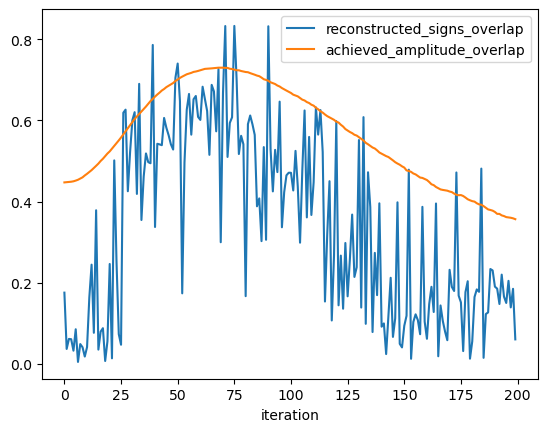

In [18]:
pd.DataFrame(out).plot(x='iteration', y=['reconstructed_signs_overlap', 'achieved_amplitude_overlap'])

In [75]:
initial_power_iterations = 50
power_iterations = 50
repetitions = len(os.sched_getaffinity(0))
number_sweeps = 500
full_iterations = 5

log_prob_fn = net_factory()
out = []
internal_out = []
# logger.info("Starting initial SWO")
# swo(
#     system=system,
#     log_prob_fn=log_prob_fn,
#     relsigns_fn=true_relsigns(system),
#     out=internal_out,
#     full_iteration=-1,
#     **(config | {"power_iterations": initial_power_iterations})
# )
# out.append(
#     {"full_iteration": -1, "amplitude_overlap": find_amplitude_overlap(system, log_prob_fn)}
# )
# logger.info(out[-1])


for full_iteration in range(full_iterations):
    logger.info(f"Starting full iteration {full_iteration}")
    logger.info("Reconstructing signs")
    if full_iteration == 0:
        random_signs_fn = np.random.choice([-1, 1], size=system.basis.states.shape[0])
    else:
        random_signs_fn = reconstruct_signs(
            system, log_prob_fn, repetitions=len(os.sched_getaffinity(0)), number_sweeps=500
        )
    # if full_iteration == 0:
    #     # Have to reset log_prob_fn to avoid leaking of true signs
    #     log_prob_fn = net_factory()

    logger.info("Starting SWO")
    swo(
        system=system,
        log_prob_fn=log_prob_fn,
        relsigns_fn=custom_signs(system, random_signs_fn),
        out=internal_out,
        full_iteration=full_iteration,
        **(config | {"power_iterations": power_iterations}),
    )
    out.append(
        {
            "full_iteration": full_iteration,
            "amplitude_overlap": find_amplitude_overlap(system, log_prob_fn),
            "sign_overlap": find_sign_overlap(system, random_signs_fn),
            "full_overlap": find_full_overlap(system, log_prob_fn, random_signs_fn),
        }
    )
    logger.info(out[-1])

2023-10-03 17:55:48.850 | INFO     | __main__:<module>:26 - Starting full iteration 0
2023-10-03 17:55:48.851 | INFO     | __main__:<module>:27 - Reconstructing signs
2023-10-03 17:55:48.854 | INFO     | __main__:<module>:38 - Starting SWO
2023-10-03 17:55:48.855 | INFO     | __main__:swo:18 - Starting SWO
2023-10-03 17:55:48.856 | INFO     | __main__:swo:21 - Running iteration 0
2023-10-03 17:55:49.554 | INFO     | __main__:swo:62 - Starting training
2023-10-03 17:55:50.121 | INFO     | __main__:swo:21 - Running iteration 1
2023-10-03 17:55:50.654 | INFO     | __main__:swo:62 - Starting training
2023-10-03 17:55:51.203 | INFO     | __main__:swo:21 - Running iteration 2
2023-10-03 17:55:51.842 | INFO     | __main__:swo:62 - Starting training
2023-10-03 17:55:52.395 | INFO     | __main__:swo:21 - Running iteration 3
2023-10-03 17:55:52.916 | INFO     | __main__:swo:62 - Starting training
2023-10-03 17:55:53.461 | INFO     | __main__:swo:21 - Running iteration 4
2023-10-03 17:55:54.009 |

/tmp/nix-shell.L0puaf/ipykernel_40542/1956575845.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


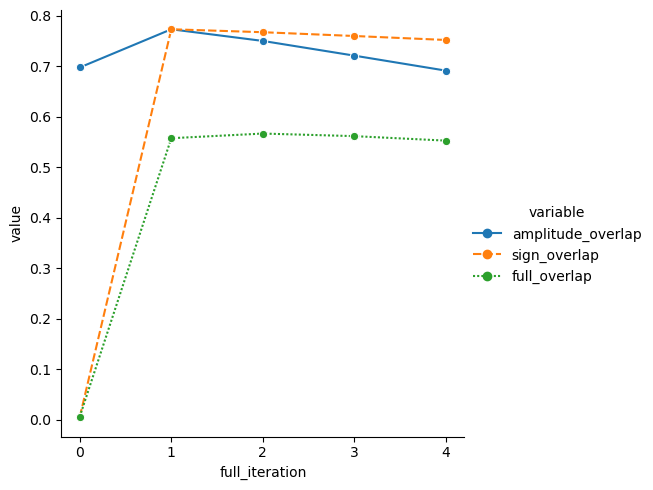

In [76]:
sns.relplot(
    pd.DataFrame(out).melt(id_vars=["full_iteration"]),
    x="full_iteration",
    y="value",
    hue="variable",
    kind="line",
    markers=["o"],
    style="variable",
)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

In [92]:
pd.DataFrame(out).assign(
    global_iteration=lambda df: df['iteration'] + df['full_iteration'] * power_iterations
)

,iteration,target_amplitude_overlap,achieved_amplitude_overlap,full_iteration,initial_amplitude_overlap,reconstructed_signs_overlap,global_iteration
0,0,0.461080,0.449520,None,0.450695,0.135148,NaN
1,1,0.459875,0.449830,None,0.449520,0.112529,NaN
2,2,0.460181,0.450418,None,0.449830,0.085162,NaN
3,3,0.460765,0.451237,None,0.450418,0.047582,NaN
4,4,0.461578,0.452102,None,0.451237,0.152342,NaN
5,5,0.462429,0.453132,None,0.452102,0.167806,NaN
6,6,0.463443,0.454763,None,0.453132,0.175764,NaN
7,7,0.465057,0.456482,None,0.454763,0.029767,NaN
8,8,0.466759,0.458358,None,0.456482,0.028951,NaN
9,9,0.468611,0.460882,None,0.458358,0.071073,NaN


KeyError: 'x'

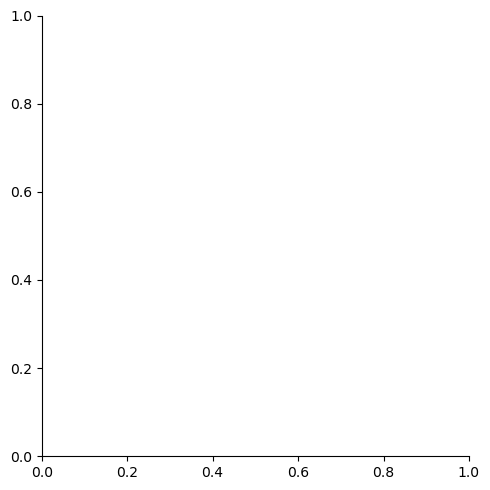

In [93]:
pd.DataFrame(out).assign(
    global_iteration=lambda df: df['iteration'] + df['full_iteration'] * power_iterations
).melt(id_vars=['iteration', 'global_iteration', 'full_iteration']).pipe(
    sns.relplot,
    x="global_iteration",
    y="value",
    kind="line",
    hue="variable",
    style="full_iteration",
    legend="full",
)

In [70]:
find_amplitude_overlap(system, log_prob_fn)

0.7794871926307678